In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re


In [3]:
data_Calls = pd.read_excel('/content/drive/MyDrive/Calls (Done).xlsx')
data_Calls.head()

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
0,5805028000000805001,30.06.2023 08:43,John Doe,NaN,Inbound,171.0,Received,NaN,NaN,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,NaN,Outbound,28.0,Attended Dialled,NaN,Completed,0.0,NaN
2,5805028000000764027,30.06.2023 08:59,John Doe,NaN,Outbound,24.0,Attended Dialled,NaN,Completed,0.0,NaN
3,5805028000000787003,30.06.2023 09:20,John Doe,5.805028e+18,Outbound,6.0,Attended Dialled,NaN,Completed,0.0,NaN
4,5805028000000768019,30.06.2023 09:30,John Doe,5.805028e+18,Outbound,11.0,Attended Dialled,NaN,Completed,0.0,NaN


In [4]:
data_Calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          95874 non-null  int64  
 1   Call Start Time             95874 non-null  object 
 2   Call Owner Name             95874 non-null  object 
 3   CONTACTID                   91941 non-null  float64
 4   Call Type                   95874 non-null  object 
 5   Call Duration (in seconds)  95791 non-null  float64
 6   Call Status                 95874 non-null  object 
 7   Dialled Number              0 non-null      float64
 8   Outgoing Call Status        86875 non-null  object 
 9   Scheduled in CRM            86875 non-null  float64
 10  Tag                         0 non-null      float64
dtypes: float64(5), int64(1), object(5)
memory usage: 8.0+ MB


In [5]:
data_Calls.describe()

,Id,CONTACTID,Call Duration (in seconds),Dialled Number,Scheduled in CRM,Tag
count,9.587400e+04,9.194100e+04,95791.000000,0.0,86875.000000,0.0
mean,5.805028e+18,5.805028e+18,164.977263,NaN,0.001635,NaN
std,1.592058e+07,1.605587e+07,401.410826,NaN,0.040397,NaN
min,5.805028e+18,5.805028e+18,0.000000,NaN,0.000000,NaN
25%,5.805028e+18,5.805028e+18,4.000000,NaN,0.000000,NaN
50%,5.805028e+18,5.805028e+18,8.000000,NaN,0.000000,NaN
75%,5.805028e+18,5.805028e+18,98.000000,NaN,0.000000,NaN
max,5.805028e+18,5.805028e+18,7625.000000,NaN,1.000000,NaN


In [6]:
data_Calls.isnull().sum()

,0
Id,0
Call Start Time,0
Call Owner Name,0
CONTACTID,3933
Call Type,0
Call Duration (in seconds),83
Call Status,0
Dialled Number,95874
Outgoing Call Status,8999
Scheduled in CRM,8999


In [7]:
# Удаляем полностью пустые колонки 'Dialled Number' и  'Tag'

data_Calls = data_Calls.drop(columns=['Dialled Number', 'Tag'])

data_Calls.head()

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM
0,5805028000000805001,30.06.2023 08:43,John Doe,NaN,Inbound,171.0,Received,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,NaN,Outbound,28.0,Attended Dialled,Completed,0.0
2,5805028000000764027,30.06.2023 08:59,John Doe,NaN,Outbound,24.0,Attended Dialled,Completed,0.0
3,5805028000000787003,30.06.2023 09:20,John Doe,5.805028e+18,Outbound,6.0,Attended Dialled,Completed,0.0
4,5805028000000768019,30.06.2023 09:30,John Doe,5.805028e+18,Outbound,11.0,Attended Dialled,Completed,0.0


In [8]:
# Преобразуем в datetime (на всякий случай) и извлекаем только дату
data_Calls['Call Start Date'] = pd.to_datetime(data_Calls['Call Start Time'], errors='coerce').dt.date




/tmp/ipykernel_699/2056316348.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_Calls['Call Start Date'] = pd.to_datetime(data_Calls['Call Start Time'], errors='coerce').dt.date


In [9]:
# Меняем тип данных
data_Calls["Call Start Time"] = pd.to_datetime(data_Calls["Call Start Time"], format="%d.%m.%Y %H:%M")

In [10]:
#новая колонка с значениями True- звонок связан с контактом, False- звонок без контакта
data_Calls['Has_Contact'] = data_Calls['CONTACTID'].notna()
data_Calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          95874 non-null  int64         
 1   Call Start Time             95874 non-null  datetime64[ns]
 2   Call Owner Name             95874 non-null  object        
 3   CONTACTID                   91941 non-null  float64       
 4   Call Type                   95874 non-null  object        
 5   Call Duration (in seconds)  95791 non-null  float64       
 6   Call Status                 95874 non-null  object        
 7   Outgoing Call Status        86875 non-null  object        
 8   Scheduled in CRM            86875 non-null  float64       
 9   Call Start Date             95874 non-null  object        
 10  Has_Contact                 95874 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), int64(1), o

In [11]:
data_Calls = data_Calls.drop_duplicates(keep='first')

# Удаляем дубликаты по ключевым столбцам
data_Calls = data_Calls.drop_duplicates(
    subset=['Call Start Time', 'Call Owner Name', 'CONTACTID', 'Call Type'],
    keep='first'
)

In [12]:
#меняем формат "CONTACTID"
data_Calls["CONTACTID"] = data_Calls["CONTACTID"].astype(str)

In [13]:
#заполняем пустые значения для "CONTACTID"  как "unknown"
data_Calls["CONTACTID"] = data_Calls["CONTACTID"].fillna("Unknown")


чтобы заполнить пропуски в 'Call Duration (in seconds)' анализируем колонку. на основе анализа понятно, что звонки с длительностью 0 это несостоявшиеся звонки, такими же являются и звонки с значениями null


In [14]:
# Фильтруем звонки, где длительность равна 0
zero_duration_calls = data_Calls[data_Calls['Call Duration (in seconds)'] == 0]

# Смотрим уникальные значения статуса таких звонков
unique_statuses = zero_duration_calls['Call Status'].unique()

print("Уникальные статусы звонков с нулевой длительностью:")
print(unique_statuses)

Уникальные статусы звонков с нулевой длительностью:
['Unattended Dialled' 'Missed' 'Scheduled Unattended'
 'Scheduled Unattended Delay']


In [15]:
# Фильтруем звонки, где длительность равна null

null_duration_calls = data_Calls[data_Calls['Call Duration (in seconds)'].isna()]

# Смотрим уникальные значения статуса таких звонков
unique_statuses = null_duration_calls['Call Status'].unique()

print("Уникальные статусы звонков с null длительностью:")
print(unique_statuses)

Уникальные статусы звонков с null длительностью:
['Cancelled' 'Overdue' 'Scheduled']


In [16]:
# заменяем пропущенные значения в колонке "Call Duration (in seconds)" на 0

data_Calls["Call Duration (in seconds)"] = data_Calls["Call Duration (in seconds)"].fillna(0)

#меняем формат "Call Duration (in seconds)" на int
data_Calls["Call Duration (in seconds)"] = data_Calls["Call Duration (in seconds)"].astype("int")

In [17]:
#заменяем пропущенные значения в столбце "Outgoing Call Status" на "Not Applicable"
data_Calls.loc[
    data_Calls["Call Status"].isin(["Missed", "Received"]) & data_Calls["Outgoing Call Status"].isna(),
    "Outgoing Call Status"
] = "Not Applicable"

пропущенные значения в "Outgoing Call Status" заменяем  на "Not Applicable". т.к. колонка показывает исходящие звонки, а пропущенными значениями являются строки с входящими

In [18]:
data_Calls["Scheduled in CRM"].info()

<class 'pandas.core.series.Series'>
Index: 87042 entries, 0 to 95873
Series name: Scheduled in CRM
Non-Null Count  Dtype  
--------------  -----  
78243 non-null  float64
dtypes: float64(1)
memory usage: 1.3 MB


"Scheduled in CRM" - это колонка с булевым значением True/False. Пропущенные значения не поддерживают этот формат, создаем идентичную категориальную колонку "Scheduled Category"

In [19]:
# Заполняем nun = "Incoming"
data_Calls["Scheduled in CRM"] = data_Calls["Scheduled in CRM"].fillna(-1)

# Добавляем категориальное поле
data_Calls["Scheduled Category"] = data_Calls["Scheduled in CRM"].map({
    1.0: "Planned",
    0.0: "Not planned",
    -1.0: "Incoming"
}).astype("category")

In [20]:
data_Calls.dtypes

,0
Id,int64
Call Start Time,datetime64[ns]
Call Owner Name,object
CONTACTID,object
Call Type,object
Call Duration (in seconds),int64
Call Status,object
Outgoing Call Status,object
Scheduled in CRM,float64
Call Start Date,object


In [21]:
#формат "CONTACTID" меняем на str
data_Calls["CONTACTID"] = data_Calls["CONTACTID"].astype("string")

In [22]:
#категориальные колонки
cat_columns = [
    "Call Owner Name",
    "Call Type",
    "Call Status",
    "Outgoing Call Status"
]
for col in cat_columns:
    data_Calls[col] = data_Calls[col].astype("category")

In [23]:
# Оставим только числовые поля
numeric_cols = ['Call Duration (in seconds)', 'Scheduled in CRM']

# Сводная статистика
summary_stats = data_Calls[numeric_cols].describe().T

# Добавим медиану, моду и диапазон вручную
summary_stats['median'] = data_Calls[numeric_cols].median()
summary_stats['mode'] = data_Calls[numeric_cols].mode().iloc[0]
summary_stats['range'] = data_Calls[numeric_cols].max() - data_Calls[numeric_cols].min()

summary_stats

,count,mean,std,min,25%,50%,75%,max,median,mode,range
Call Duration (in seconds),87042.0,174.586855,411.408859,0.0,4.0,9.0,116.0,7625.0,9.0,0.0,7625.0
Scheduled in CRM,87042.0,-0.099550,0.304499,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0


In [24]:
# Средняя длительность звонка по каждому менеджеру
avg_duration_per_manager = (
    data_Calls.groupby('Call Owner Name')['Call Duration (in seconds)']
    .mean()
    .reset_index()
    .sort_values(by='Call Duration (in seconds)', ascending=False)
)

/tmp/ipykernel_699/897117596.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_Calls.groupby('Call Owner Name')['Call Duration (in seconds)']


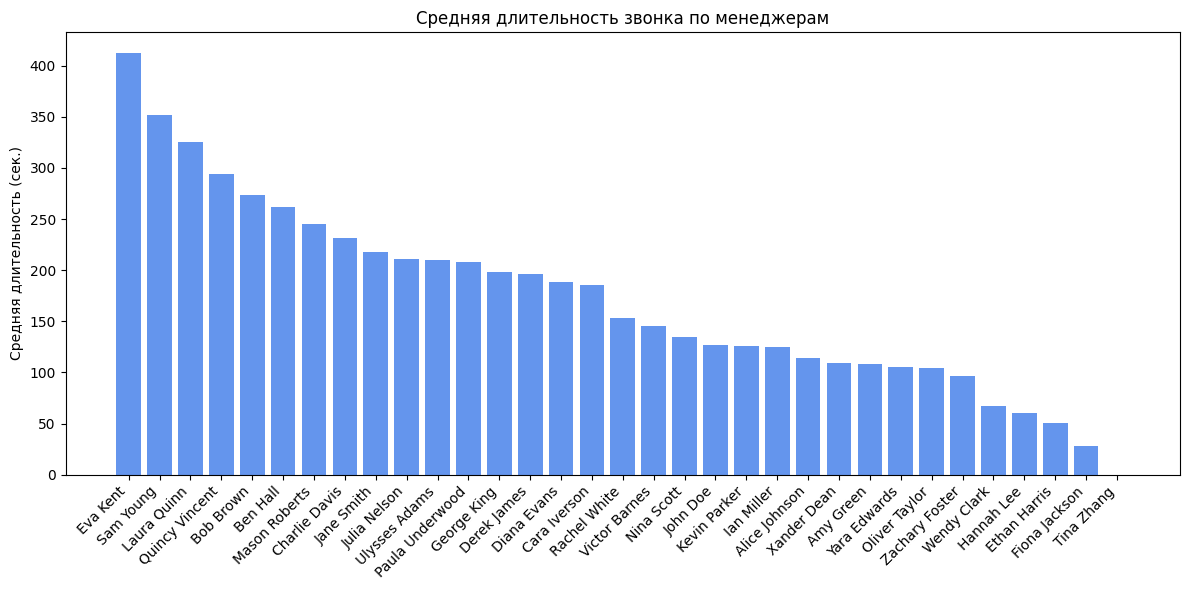

In [25]:
plt.figure(figsize=(12,6))
plt.bar(avg_duration_per_manager['Call Owner Name'],
        avg_duration_per_manager['Call Duration (in seconds)'],
        color='cornflowerblue')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Средняя длительность (сек.)')
plt.title('Средняя длительность звонка по менеджерам')
plt.tight_layout()
plt.show()

In [26]:


data_Calls.head()

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM,Call Start Date,Has_Contact,Scheduled Category
0,5805028000000805001,2023-06-30 08:43:00,John Doe,nan,Inbound,171,Received,Not Applicable,-1.0,2023-06-30,False,Incoming
1,5805028000000768006,2023-06-30 08:46:00,John Doe,nan,Outbound,28,Attended Dialled,Completed,0.0,2023-06-30,False,Not planned
2,5805028000000764027,2023-06-30 08:59:00,John Doe,nan,Outbound,24,Attended Dialled,Completed,0.0,2023-06-30,False,Not planned
3,5805028000000787003,2023-06-30 09:20:00,John Doe,5.805028000000645e+18,Outbound,6,Attended Dialled,Completed,0.0,2023-06-30,True,Not planned
4,5805028000000768019,2023-06-30 09:30:00,John Doe,5.805028000000645e+18,Outbound,11,Attended Dialled,Completed,0.0,2023-06-30,True,Not planned


In [27]:
data_Spend = pd.read_excel('/content/drive/MyDrive/Spend (Done).xlsx')
data_Spend.head()

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN
3,2023-07-03,Google Ads,NaN,0,0.00,0,NaN,NaN
4,2023-07-03,CRM,NaN,0,0.00,0,NaN,NaN


In [28]:
data_Spend = data_Spend.drop_duplicates(keep='first')

In [29]:
# убираем дубликаты по ключевым полям
data_Spend = data_Spend.drop_duplicates(
    subset=['Date', 'Campaign', 'Source', 'AdGroup', 'Ad'],
    keep='first'
)


In [30]:
data_Spend.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18777 entries, 0 to 20778
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         18777 non-null  datetime64[ns]
 1   Source       18777 non-null  object        
 2   Campaign     14770 non-null  object        
 3   Impressions  18777 non-null  int64         
 4   Spend        18777 non-null  float64       
 5   Clicks       18777 non-null  int64         
 6   AdGroup      13936 non-null  object        
 7   Ad           13936 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 1.3+ MB


In [31]:
data_Spend.dtypes

,0
Date,datetime64[ns]
Source,object
Campaign,object
Impressions,int64
Spend,float64
Clicks,int64
AdGroup,object
Ad,object


In [32]:
data_Spend.isnull().sum()


,0
Date,0
Source,0
Campaign,4007
Impressions,0
Spend,0
Clicks,0
AdGroup,4841
Ad,4841


In [33]:
data_Spend['Source'].unique()

array(['Google Ads', 'Facebook Ads', 'CRM', 'Bloggers', 'Youtube Ads',
       'SMM', 'Tiktok Ads', 'Organic', 'Telegram posts', 'Webinar',
       'Offline', 'Partnership', 'Test', 'Radio'], dtype=object)

In [34]:
data_Spend['Source'] = data_Spend['Source'].astype('category')

In [35]:
data_Spend['Campaign'].unique()

array(['gen_analyst_DE', 'performancemax_eng_DE', nan, '03.07.23women',
       '02.07.23wide_DE', '12.07.2023wide_DE', '05.07.23interests_DE',
       '04.07.23recentlymoved_DE', '07.07.23LAL_DE',
       '10.07.23wide_com_DE', '15.07.23b_DE', 'youtube_shorts_DE',
       '24.07.2023wide_DE', 'comp_search_DE', 'brand_search_eng_DE',
       '02.08.23interests_DE', 'web2408_DE', '05.09.2023wide_DE',
       '12.09.23interests_Uxui_DE', 'discovery_DE',
       '24.09.23retargeting_DE', '18.10.23wide_gos_DE',
       '14.11.23wide_webinar_DE', '15.11.23wide_webinar_DE', 'blog2_DE',
       '30.11.23wide_DE', '07.12.23test_DE', '01.02.24wide_webinar_DE',
       'bbo_DE', '09.02.24berlin_dd_DE', '17.03.24wide_AT',
       '15.03.24recentlymoved_AT', '15.03.2024wide_AT',
       'youtube_shortsin_AT', 'discovery_wide1_AT',
       'performancemax_wide_AT', '20.03.24_widde_PL', '20.03.2024wide_PL',
       '20.03.24interests_WebDev_AT', '20.03.24interests_WebDev_PL',
       'shorts_PL', '1performancemax_

In [36]:
data_Spend['Campaign'] = data_Spend['Campaign'].fillna('unknown')

data_Spend['Campaign'] = data_Spend['Campaign'].astype('category')

In [37]:
pd.options.display.float_format = '{:.2f}'.format
data_Spend['Spend'] = (
    data_Spend['Spend']
    .astype(str)                          # приводим всё к строке
    .str.replace('€','e' '', regex=False)    # убираем символ €
    .str.replace(',', '.', regex=False))   # заменяем запятую на точку (для десятичных)


In [38]:
data_Spend['Spend'] = data_Spend['Spend'].astype(float)

In [39]:
data_Spend['AdGroup'].unique()

array([nan, 'women', 'wide', 'interest_programming', 'recentlymoved',
       'interest_dataanalytics', 'interest_work',
       'interest_programming – Copy', 'interest_dataanalytics – Copy',
       'LAL1', 'b', 'Com_july_1', 'interest_all', 'Com_august',
       'interest_work_WebDev', 'interest_programming_WebDev',
       'promoposts_b', 'retargeting', 'wide_webdesigner',
       'wide_python-developer', 'wide_qa-engineer',
       'interest_python-developer', 'berlin_wide', 'Com_march',
       'accountant_wide'], dtype=object)

In [40]:
def normalize_adgroup(value):
    if pd.isna(value):
        return None

    text = str(value).strip().lower()

    # Удаляем фразу "copy" и её вариации
    text = re.sub(r'_?copy_?', '', text)

    # Убираем всё, кроме латиницы, цифр и подчеркиваний
    text = re.sub(r'[^a-z0-9_]+', '', text)

    return text if text else None


# Применяем к колонке
data_Spend['AdGroup'] = data_Spend['AdGroup'].apply(normalize_adgroup)
data_Spend['AdGroup'].unique()

array([None, 'women', 'wide', 'interest_programming', 'recentlymoved',
       'interest_dataanalytics', 'interest_work', 'lal1', 'b',
       'com_july_1', 'interest_all', 'com_august', 'interest_work_webdev',
       'interest_programming_webdev', 'promoposts_b', 'retargeting',
       'wide_webdesigner', 'wide_pythondeveloper', 'wide_qaengineer',
       'interest_pythondeveloper', 'berlin_wide', 'com_march',
       'accountant_wide'], dtype=object)

In [41]:
#заполняем пустые значения
data_Spend['AdGroup'] = data_Spend['AdGroup'].fillna('unknown')

#переводим в категориальный формат
data_Spend['AdGroup'] = data_Spend['AdGroup'].astype('category')

In [42]:
data_Spend['Ad'].unique()

array([nan, 'b3', 'b1', 'b4', 'b2', 'v2', 'v1', 'b4com', 'b3com', 'b2com',
       'b1com', 'v6com', 'v5', 'v4com', 'v3com', 'v5com', 'ad4', 'ad1',
       'ad2', 'ad3', 'v8com', 'v7com', 'ad6', 'ad5', 'bloggersvideo1com',
       'v9com', 'ad9', 'ad8', 'ad_blogger_1', 'ad_blogger_2', 'ad7',
       'web_b3', 'web_b5', 'web_b1', 'web_b4', 'web_b2', 'ad_blogger_3',
       'v10com', 'bloggersvideo2com', 'b5', 'b6', 'b8', 'b7', 'v3', 'v10',
       'v12', 'v11com', 'v11', 'ad_gov_1', 'ad_da_1', 'b3comwebdev',
       'bloggersvideo2comwebdev', 'v11comwebdev', 'b1comwebdev',
       'b2comwebdev', 'bloggersvideo4com', 'bloggersvideo3com',
       'bloggersvideo5', 'promo2', 'promo1', 'ad_blogger_4',
       'bloggersvideo4', 'b10', 'b11', 'b12', 'ad_blogger_6', 'promo3',
       'b15blackfriday', 'b14blackfriday', 'b13blackfriday', 'b7webinar',
       'b6webinar', 'b4webinar', 'b5webinar', 'bloggersvideo6blackfriday',
       'bloggersvideo6webinar', 'bloggersvideo7blackfriday',
       'bloggersvideo

In [43]:
#заполняем пропущеные значения
data_Spend['Ad'] = data_Spend['Ad'].fillna('unknown')

#переводим в категориальный формат
data_Spend['Ad'] = data_Spend['Ad'].astype('category')

In [44]:
data_Spend.isnull().sum()

,0
Date,0
Source,0
Campaign,0
Impressions,0
Spend,0
Clicks,0
AdGroup,0
Ad,0


In [45]:
data_Spend.dtypes

,0
Date,datetime64[ns]
Source,category
Campaign,category
Impressions,int64
Spend,float64
Clicks,int64
AdGroup,category
Ad,category


In [46]:
#сохраняем очищенные данные
data_Calls.to_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Calls_cleaned.xlsx', index=0)

data_Spend.to_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Spend_cleaned.xlsx', index=0)

